# BCemu Spectra Module Demo

Full matter power spectrum P(k,z) and CMB spectra with baryonic feedback.

**Requires:** `pip install BCemu[spectra]`

**Panels per model:**
- **a)** Baryonic suppression S(k) — three panels, one per redshift
- **b)** CMB lensing convergence C_ℓ^κκ — full spectrum (top) + ratio to DMO (bottom)
- **c)** Primary CMB TT, EE, TE with lensed/unlensed — full (top row) + ratio to DMO (bottom row)

**Models:** 1. HydroSimCAMB — 2. BCemuCAMB (BCemu2025, varying log₁₀Mϲ)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import BCemu

%matplotlib inline
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 9,
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
})

k      = np.geomspace(0.01, 50.0, 300)   # Mpc^-1
z_arr  = np.array([0.0, 0.5, 1.0])
Z_LABELS = [r'$z = 0$', r'$z = 0.5$', r'$z = 1$']
COLORS   = plt.get_cmap('tab10').colors

LW_DMO        = 2.5
LW_DMO_UN     = 1.5
LW_MOD        = 1.5
LW_MOD_UN     = 1.0
ALPHA_UN      = 0.5

In [2]:
# ── DMO baseline (no feedback) ──────────────────────────────────────────────
print('Running DMO baseline…')
base     = BCemu.BaryonicCAMB(lmax=6000, kmax=50.0)
pk_base  = base.matter_spectrum(k, z_arr)
cmb_dmo  = base.cmb_spectrum(lmax=6000)

ell      = cmb_dmo['ell']
mask     = ell >= 2
prefactor = ell * (ell + 1) / (2 * np.pi)
print('Baseline done.')

Running DMO baseline…
Setting up CAMB (background + CMB transfer functions)...
Building matter power spectrum grids...
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Ready.
  Computing C_L^kk via Limber integral... done.
Baseline done.


---
## 1. HydroSimCAMB

In [3]:
PREFERRED_SIMS = ['TNG100', 'EAGLE', 'BAHAMAS_AGN7.8', 'HorizonAGN', 'FLAMINGO_L1_m9']
available  = BCemu.HydroSimDataSk.available()
SIM_NAMES  = [s for s in PREFERRED_SIMS if s in available]
print('Simulations:', SIM_NAMES)

hydro_models, hydro_Sk, hydro_cmb = {}, {}, {}
for sim in SIM_NAMES:
    print(f'  {sim}…')
    m = BCemu.HydroSimCAMB(sim, lmax=6000, kmax=50.0)
    hydro_models[sim] = m
    hydro_Sk[sim]     = m.S(k, z_arr)          # (n_z, n_k)
    hydro_cmb[sim]    = m.cmb_spectrum(lmax=6000)
print('Done.')

Simulations: ['TNG100', 'EAGLE', 'BAHAMAS_AGN7.8', 'HorizonAGN', 'FLAMINGO_L1_m9']
  TNG100…
Setting up CAMB (background + CMB transfer functions)...
Building matter power spectrum grids...
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Ready.
  Loading BCemu data for TNG100... done.
HydroSimCAMB (TNG100) ready.
  Computing C_L^kk via Limber integral... done.
  EAGLE…
Setting up CAMB (background + CMB transfer functions)...
Building matter power spectrum grids...
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Ready.
  Loading BCemu data for EAGLE... done.
HydroSimCAMB (EAGLE) ready.
  Computing C_L^kk via Limber integral... done.
  BAHAMAS_AGN7.8…
Setting up CAMB (background + CMB transfer functions)...
Building matter power spectrum grids...
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Ready.
  Loading BCemu 

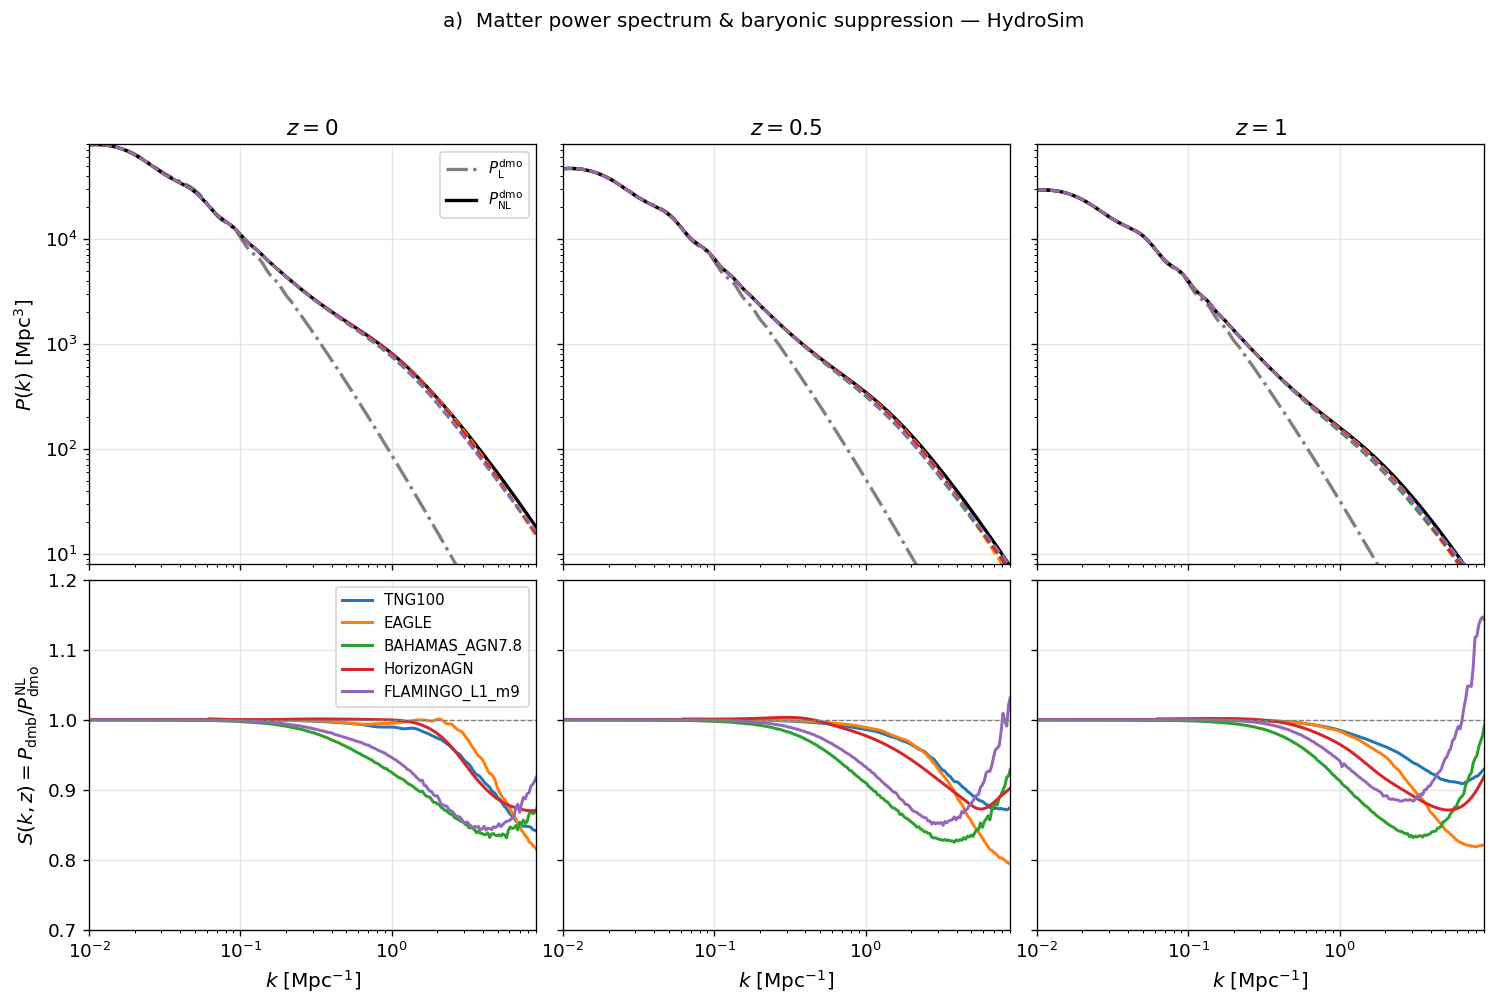

In [4]:
# ── a) Matter P(k) + baryonic suppression S(k) — HydroSim ───────────────────
fig = plt.figure(figsize=(15, 8.5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.04, wspace=0.06,
                        height_ratios=[1.2, 1.0])

# Build axes — share x within each column, y within each row
axes_pk, axes_sk = [], []
for j in range(3):
    ax_pk = fig.add_subplot(gs[0, j], sharey=(axes_pk[0] if j else None))
    ax_sk = fig.add_subplot(gs[1, j], sharex=ax_pk,
                            sharey=(axes_sk[0] if j else None))
    axes_pk.append(ax_pk)
    axes_sk.append(ax_sk)

for iz, (ax_pk, ax_sk, zlbl) in enumerate(zip(axes_pk, axes_sk, Z_LABELS)):
    # ── top row: linear DM, nonlinear DM, baryon+DM ──────────────────────────
    ax_pk.loglog(k, pk_base['P_L_dmo'][iz], color='gray', ls='-.', lw=2.0,
                 label=r'$P_{\rm L}^{\rm dmo}$'  if iz == 0 else None)
    ax_pk.loglog(k, pk_base['P_NL_dmo'][iz], color='black', ls='-', lw=2.0,
                 label=r'$P_{\rm NL}^{\rm dmo}$' if iz == 0 else None)
    for ci, sim in enumerate(SIM_NAMES):
        pk_dmb = pk_base['P_NL_dmo'][iz] * hydro_Sk[sim][iz]
        ax_pk.loglog(k, pk_dmb, color=COLORS[ci], ls='--', lw=1.5)
    ax_pk.set_xlim(0.01, 9)
    ax_pk.set_ylim(8, 8e4)
    ax_pk.set_title(zlbl, fontsize=13)
    plt.setp(ax_pk.get_xticklabels(), visible=False)
    if iz > 0:
        plt.setp(ax_pk.get_yticklabels(), visible=False)

    # ── bottom row: S(k) ─────────────────────────────────────────────────────
    for ci, sim in enumerate(SIM_NAMES):
        kw = {'label': sim} if iz == 0 else {}
        ax_sk.semilogx(k, hydro_Sk[sim][iz], color=COLORS[ci], lw=1.8, **kw)
    ax_sk.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax_sk.set_xlabel(r'$k$ [Mpc$^{-1}$]')
    ax_sk.set_ylim(0.70, 1.2)
    if iz > 0:
        plt.setp(ax_sk.get_yticklabels(), visible=False)

axes_pk[0].set_ylabel(r'$P(k)$ [Mpc$^3$]')
axes_pk[0].legend(fontsize=9)
axes_sk[0].set_ylabel(r'$S(k,z) = P_{\rm dmb}/P^{\rm NL}_{\rm dmo}$')
axes_sk[0].legend()
fig.suptitle('a)  Matter power spectrum & baryonic suppression — HydroSim',
             y=1.01, fontsize=12)
plt.show()


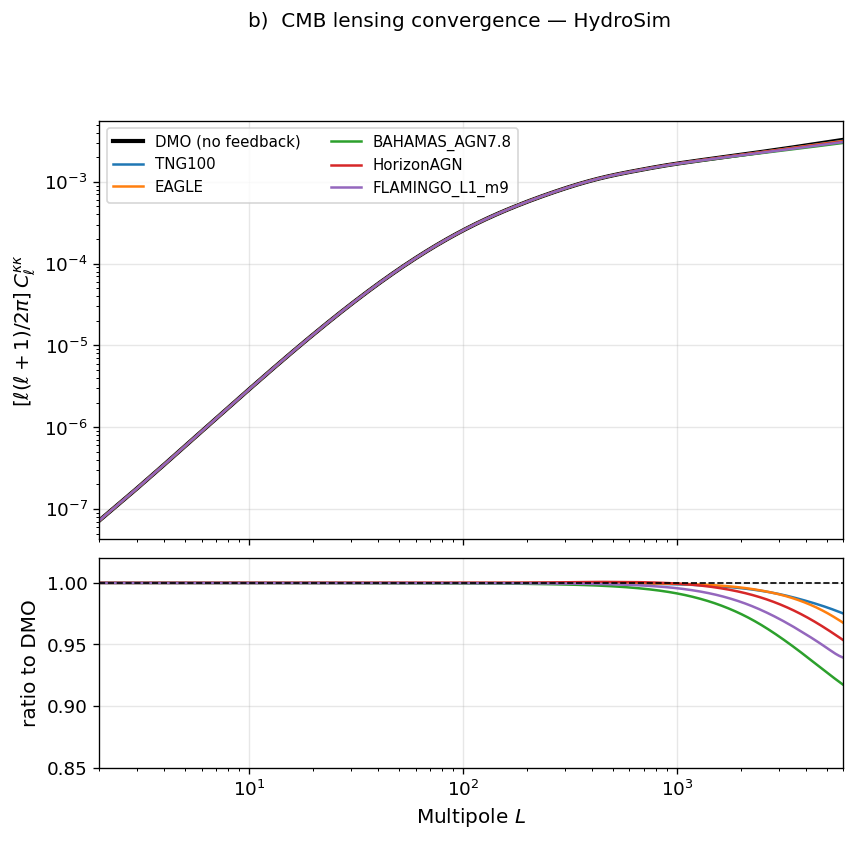

In [5]:
# ── b) CMB lensing — full (top) + ratio (bottom) ─────────────────────────────
fig = plt.figure(figsize=(8, 7))
gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.06)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# full spectrum
ax_top.loglog(ell[mask], (prefactor * cmb_dmo['C_kappakappa'])[mask],
              'k-', lw=LW_DMO, label='DMO (no feedback)')
for ci, sim in enumerate(SIM_NAMES):
    ax_top.loglog(ell[mask], (prefactor * hydro_cmb[sim]['C_kappakappa'])[mask],
                  color=COLORS[ci], lw=LW_MOD, label=sim)

# ratio
ckk_dmo = cmb_dmo['C_kappakappa'][mask]
for ci, sim in enumerate(SIM_NAMES):
    ratio = hydro_cmb[sim]['C_kappakappa'][mask] / ckk_dmo
    ax_bot.plot(ell[mask], ratio, color=COLORS[ci], lw=LW_MOD)
ax_bot.axhline(1.0, color='k', lw=1.0, ls='--')

ax_top.set_ylabel(r'$[\ell(\ell+1)/2\pi]\,C_\ell^{\kappa\kappa}$')
ax_bot.set_ylabel(r'ratio to DMO')
ax_bot.set_xlabel(r'Multipole $L$')
ax_bot.set_xlim(2, 6000)
ax_bot.set_ylim(0.85, 1.02)
ax_top.legend(ncol=2)
plt.setp(ax_top.get_xticklabels(), visible=False)
fig.suptitle('b)  CMB lensing convergence — HydroSim', y=1.01, fontsize=12)
plt.show()

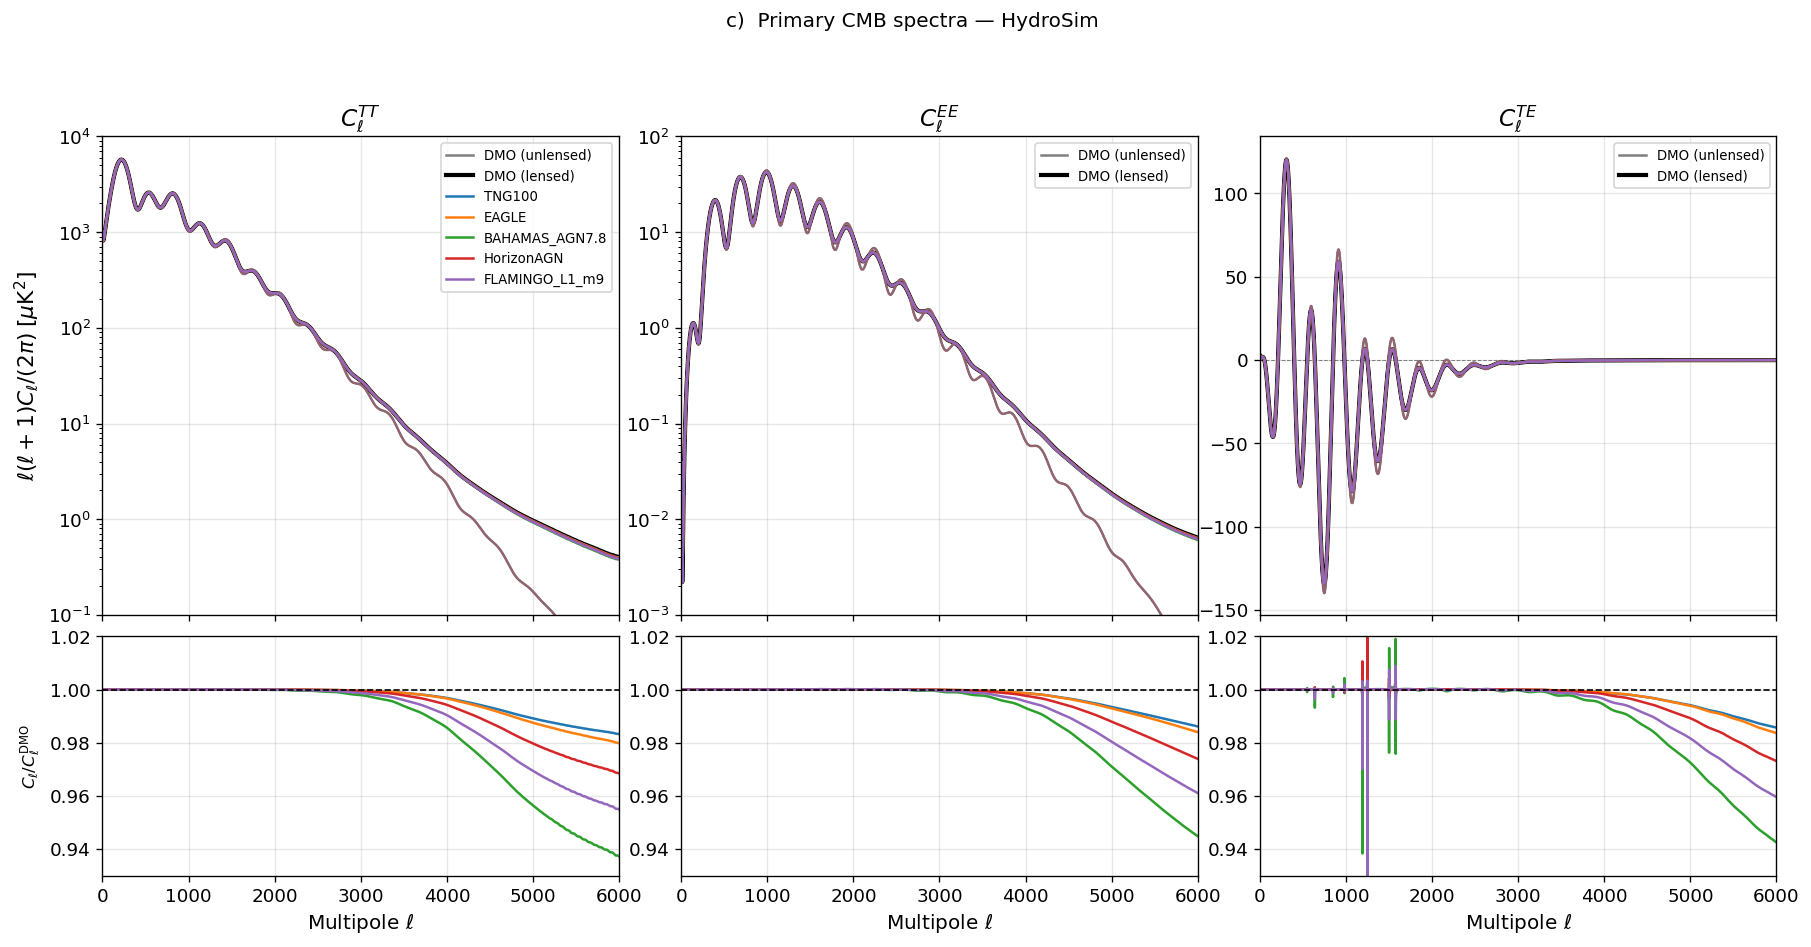

In [6]:
# ── c) TT, EE, TE — full + ratio ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8))
gs  = gridspec.GridSpec(2, 3, height_ratios=[2, 1], hspace=0.06, wspace=0.12)

ax_tt  = fig.add_subplot(gs[0, 0])
ax_ee  = fig.add_subplot(gs[0, 1])
ax_te  = fig.add_subplot(gs[0, 2])
ax_rtt = fig.add_subplot(gs[1, 0], sharex=ax_tt)
ax_ree = fig.add_subplot(gs[1, 1], sharex=ax_ee)
ax_rte = fig.add_subplot(gs[1, 2], sharex=ax_te)

# ── TT ───────────────────────────────────────────────────────────────────────
ax_tt.plot(ell[mask], (prefactor * cmb_dmo['C_TT_unlensed'])[mask],
           'k-', lw=LW_DMO_UN, alpha=ALPHA_UN, label='DMO (unlensed)')
ax_tt.plot(ell[mask], (prefactor * cmb_dmo['C_TT'])[mask],
           'k-', lw=LW_DMO, label='DMO (lensed)')
for ci, sim in enumerate(SIM_NAMES):
    ax_tt.plot(ell[mask], (prefactor * hydro_cmb[sim]['C_TT_unlensed'])[mask],
               color=COLORS[ci], lw=LW_MOD_UN, alpha=ALPHA_UN)
    ax_tt.plot(ell[mask], (prefactor * hydro_cmb[sim]['C_TT'])[mask],
               color=COLORS[ci], lw=LW_MOD, label=sim)
ax_tt.set_yscale('log')
ax_tt.set_xlim(0, 6010)
ax_tt.set_ylim(1e-1, 1e4)
ax_tt.set_title(r'$C_\ell^{TT}$', fontsize=14)
ax_tt.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)\;[\mu{\rm K}^2]$', fontsize=13)
ax_tt.legend(fontsize=8)

# ── EE ───────────────────────────────────────────────────────────────────────
ax_ee.plot(ell[mask], (prefactor * cmb_dmo['C_EE_unlensed'])[mask],
           'k-', lw=LW_DMO_UN, alpha=ALPHA_UN, label='DMO (unlensed)')
ax_ee.plot(ell[mask], (prefactor * cmb_dmo['C_EE'])[mask],
           'k-', lw=LW_DMO, label='DMO (lensed)')
for ci, sim in enumerate(SIM_NAMES):
    ax_ee.plot(ell[mask], (prefactor * hydro_cmb[sim]['C_EE_unlensed'])[mask],
               color=COLORS[ci], lw=LW_MOD_UN, alpha=ALPHA_UN)
    ax_ee.plot(ell[mask], (prefactor * hydro_cmb[sim]['C_EE'])[mask],
               color=COLORS[ci], lw=LW_MOD)
ax_ee.set_yscale('log')
ax_ee.set_xlim(0, 6010)
ax_ee.set_ylim(1e-3, 1e2)
ax_ee.set_title(r'$C_\ell^{EE}$', fontsize=14)
ax_ee.legend(fontsize=8)

# ── TE ───────────────────────────────────────────────────────────────────────
ax_te.axhline(0, color='gray', lw=0.6, ls='--')
ax_te.plot(ell[mask], (prefactor * cmb_dmo['C_TE_unlensed'])[mask],
           'k-', lw=LW_DMO_UN, alpha=ALPHA_UN, label='DMO (unlensed)')
ax_te.plot(ell[mask], (prefactor * cmb_dmo['C_TE'])[mask],
           'k-', lw=LW_DMO, label='DMO (lensed)')
for ci, sim in enumerate(SIM_NAMES):
    ax_te.plot(ell[mask], (prefactor * hydro_cmb[sim]['C_TE_unlensed'])[mask],
               color=COLORS[ci], lw=LW_MOD_UN, alpha=ALPHA_UN)
    ax_te.plot(ell[mask], (prefactor * hydro_cmb[sim]['C_TE'])[mask],
               color=COLORS[ci], lw=LW_MOD)
ax_te.set_xlim(0, 6010)
ax_te.set_title(r'$C_\ell^{TE}$', fontsize=14)
ax_te.legend(fontsize=8)

# ── ratio rows ───────────────────────────────────────────────────────────────
C_TT_dmo = cmb_dmo['C_TT'][mask]
C_EE_dmo = cmb_dmo['C_EE'][mask]
C_TE_dmo = cmb_dmo['C_TE'][mask]

for ci, sim in enumerate(SIM_NAMES):
    ax_rtt.plot(ell[mask], hydro_cmb[sim]['C_TT'][mask] / C_TT_dmo,
                color=COLORS[ci], lw=LW_MOD)
    ax_ree.plot(ell[mask], hydro_cmb[sim]['C_EE'][mask] / C_EE_dmo,
                color=COLORS[ci], lw=LW_MOD)
    ax_rte.plot(ell[mask], hydro_cmb[sim]['C_TE'][mask] / C_TE_dmo,
                color=COLORS[ci], lw=LW_MOD)

for ax_r, ylabel in [
    (ax_rtt, r'$C_\ell/C_\ell^{\rm DMO}$'),
    (ax_ree, None),
    (ax_rte, None),
]:
    ax_r.axhline(1.0, color='k', lw=1.0, ls='--')
    ax_r.set_xlim(0, 6000)
    ax_r.set_ylim(0.93, 1.02)
    ax_r.set_xlabel(r'Multipole $\ell$', fontsize=12)
    ax_r.set_ylabel(ylabel, fontsize=10)

for ax_top in (ax_tt, ax_ee, ax_te):
    plt.setp(ax_top.get_xticklabels(), visible=False)

fig.suptitle('c)  Primary CMB spectra — HydroSim', y=1.01, fontsize=12)
plt.show()

---
## 2. BCemuCAMB

In [7]:
N_CURVES = 5   # number of lines per parameter sweep
CMAP_NAME = 'plasma_r'

Ob, Om = 0.0486, 0.306
BCM_BASE = {
    'Theta_co': 0.3, 'log10Mc': 13.1, 'mu': 1.0,
    'delta': 6.0,   'eta': 0.10,     'deta': 0.22,
    'Nstar': 0.028, 'fb': Ob / Om,
}

LOG10MC_VALS = np.linspace(12.0, 14.5, N_CURVES)
EMU_LABELS   = [rf'$\log_{{10}}M_c = {v:.2f}$' for v in LOG10MC_VALS]

# ── Fiducial model — CAMB runs once here; reused for all parameter sweeps ─────
print(f'Initialising BCemuCAMB fiducial (log10Mc={BCM_BASE["log10Mc"]})…')
fid_model = BCemu.BCemuCAMB(BCM_BASE, baryonic_feedback='BCemu2025', q2=0.70,
                             lmax=6000, kmax=50.0)
cmb_fid = fid_model.cmb_spectrum(lmax=6000)
Sk_fid  = fid_model.S(k, z_arr)
print('Fiducial done.')

# ── log10Mc sweep — reuse CAMB via update_bcm_params (no second CAMB run) ─────
emu_Sk, emu_cmb = {}, {}
for mc in LOG10MC_VALS:
    key = f'mc{mc:.2f}'
    print(f'  log10Mc={mc:.2f}…', end=' ', flush=True)
    fid_model.update_bcm_params({**BCM_BASE, 'log10Mc': mc})
    emu_Sk[key]  = fid_model.S(k, z_arr)
    emu_cmb[key] = fid_model.cmb_spectrum(lmax=6000)
    print('done')

fid_model.update_bcm_params(BCM_BASE)   # restore fiducial
print('log10Mc sweep done.')

Initialising BCemuCAMB fiducial (log10Mc=13.1)…
Setting up CAMB (background + CMB transfer functions)...
Building matter power spectrum grids...
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Ready.
Building BCemu (BCemu2025) suppression grid...
Loading BCemu2025 models (backend='numpy')...


Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

...BCemu2025 emulator is ready.
BCemuCAMB (BCemu2025) ready.
  Computing C_L^kk via Limber integral... done.
Fiducial done.
  log10Mc=12.00…   Computing C_L^kk via Limber integral... done.
done
  log10Mc=12.62…   Computing C_L^kk via Limber integral... done.
done
  log10Mc=13.25…   Computing C_L^kk via Limber integral... done.
done
  log10Mc=13.88…   Computing C_L^kk via Limber integral... done.
done
  log10Mc=14.50…   Computing C_L^kk via Limber integral... done.
done
log10Mc sweep done.


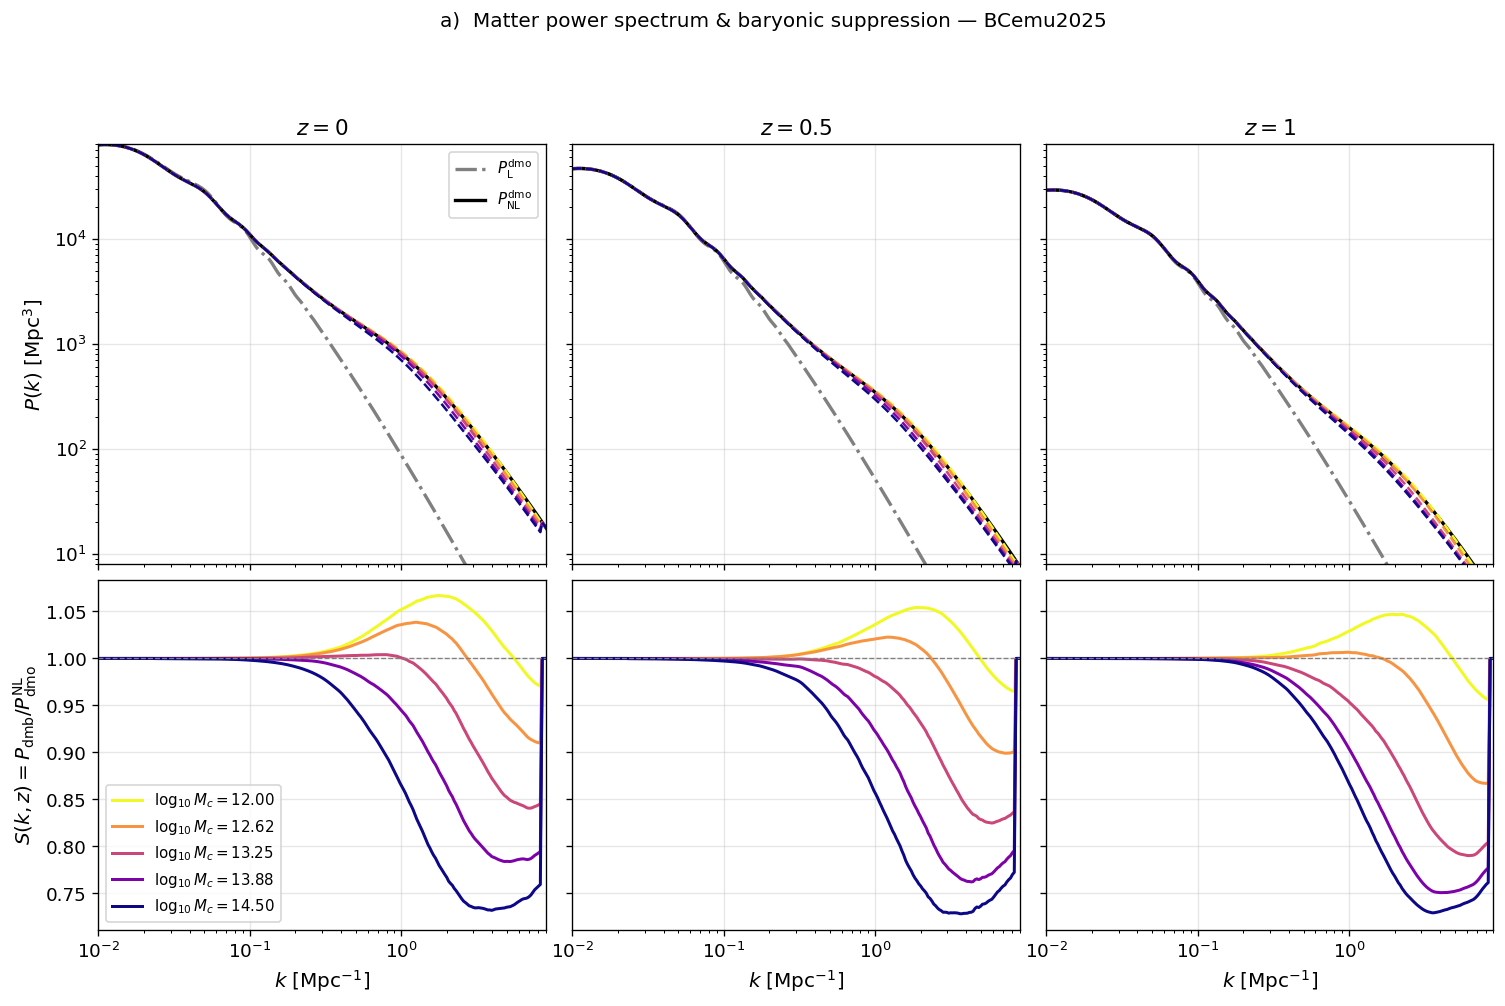

In [8]:
# ── a) Matter P(k) + baryonic suppression S(k) — BCemu2025 ───────────────────
mc_min, mc_max = LOG10MC_VALS[0], LOG10MC_VALS[-1]
cmap_mc  = plt.get_cmap(CMAP_NAME)
norm_mc  = plt.Normalize(vmin=mc_min, vmax=mc_max)
mc_colors = [cmap_mc(norm_mc(mc)) for mc in LOG10MC_VALS]

fig = plt.figure(figsize=(15, 8.5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.04, wspace=0.06,
                        height_ratios=[1.2, 1.0])

# Build axes — share x within each column, y within each row
axes_pk, axes_sk = [], []
for j in range(3):
    ax_pk = fig.add_subplot(gs[0, j], sharey=(axes_pk[0] if j else None))
    ax_sk = fig.add_subplot(gs[1, j], sharex=ax_pk,
                            sharey=(axes_sk[0] if j else None))
    axes_pk.append(ax_pk)
    axes_sk.append(ax_sk)

for iz, (ax_pk, ax_sk, zlbl) in enumerate(zip(axes_pk, axes_sk, Z_LABELS)):
    # ── top row: linear DM, nonlinear DM, baryon+DM ──────────────────────────
    ax_pk.loglog(k, pk_base['P_L_dmo'][iz], color='gray', ls='-.', lw=2.0,
                 label=r'$P_{\rm L}^{\rm dmo}$'  if iz == 0 else None)
    ax_pk.loglog(k, pk_base['P_NL_dmo'][iz], color='black', ls='-', lw=2.0,
                 label=r'$P_{\rm NL}^{\rm dmo}$' if iz == 0 else None)
    for ci, (mc, lbl) in enumerate(zip(LOG10MC_VALS, EMU_LABELS)):
        key = f'mc{mc:.2f}'
        pk_dmb = pk_base['P_NL_dmo'][iz] * emu_Sk[key][iz]
        ax_pk.loglog(k, pk_dmb, color=mc_colors[ci], ls='--', lw=1.5)
    ax_pk.set_xlim(0.01, 9)
    ax_pk.set_ylim(8, 8e4)
    ax_pk.set_title(zlbl, fontsize=13)
    plt.setp(ax_pk.get_xticklabels(), visible=False)
    if iz > 0:
        plt.setp(ax_pk.get_yticklabels(), visible=False)

    # ── bottom row: S(k) ─────────────────────────────────────────────────────
    for ci, (mc, lbl) in enumerate(zip(LOG10MC_VALS, EMU_LABELS)):
        key = f'mc{mc:.2f}'
        kw  = {'label': lbl} if iz == 0 else {}
        ax_sk.semilogx(k, emu_Sk[key][iz], color=mc_colors[ci], lw=1.8, **kw)
    ax_sk.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax_sk.set_xlabel(r'$k$ [Mpc$^{-1}$]')
    if iz > 0:
        plt.setp(ax_sk.get_yticklabels(), visible=False)

axes_pk[0].set_ylabel(r'$P(k)$ [Mpc$^3$]')
axes_pk[0].legend(fontsize=9)
axes_sk[0].set_ylabel(r'$S(k,z) = P_{\rm dmb}/P^{\rm NL}_{\rm dmo}$')
axes_sk[0].legend()
fig.suptitle('a)  Matter power spectrum & baryonic suppression — BCemu2025',
             y=1.01, fontsize=12)
plt.show()


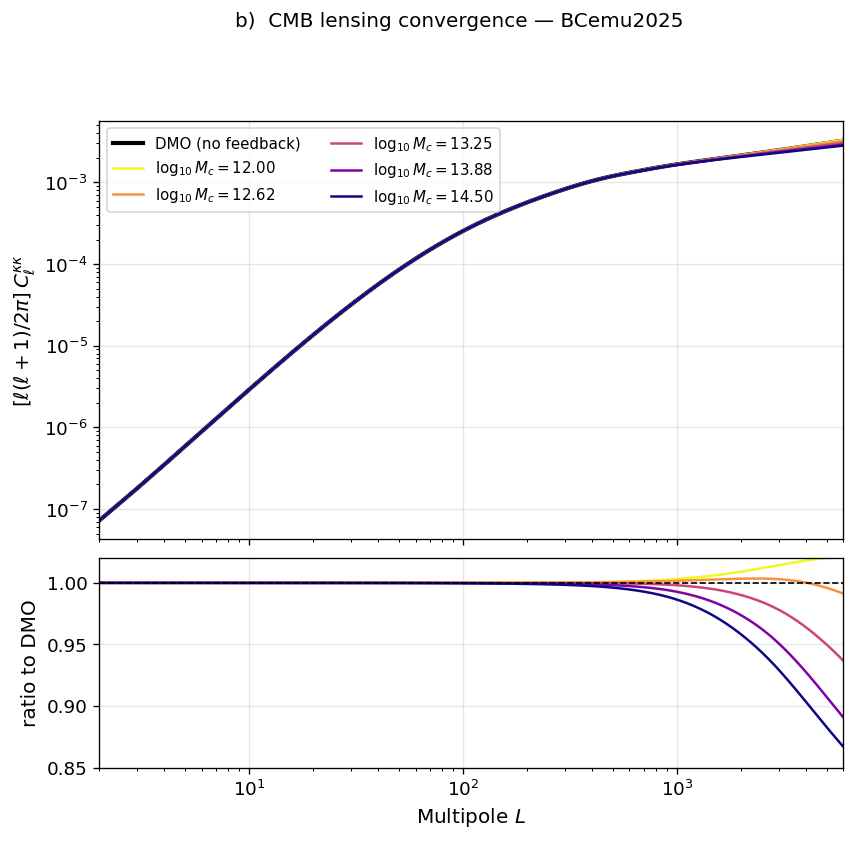

In [9]:
# ── b) CMB lensing — full (top) + ratio (bottom) ─────────────────────────────
fig = plt.figure(figsize=(8, 7))
gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.06)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

ax_top.loglog(ell[mask], (prefactor * cmb_dmo['C_kappakappa'])[mask],
              'k-', lw=LW_DMO, label='DMO (no feedback)')
for ci, (mc, lbl) in enumerate(zip(LOG10MC_VALS, EMU_LABELS)):
    key = f'mc{mc:.2f}'
    ax_top.loglog(ell[mask], (prefactor * emu_cmb[key]['C_kappakappa'])[mask],
                  color=mc_colors[ci], lw=LW_MOD, label=lbl)

ckk_dmo = cmb_dmo['C_kappakappa'][mask]
for ci, mc in enumerate(LOG10MC_VALS):
    key   = f'mc{mc:.2f}'
    ratio = emu_cmb[key]['C_kappakappa'][mask] / ckk_dmo
    ax_bot.plot(ell[mask], ratio, color=mc_colors[ci], lw=LW_MOD)
ax_bot.axhline(1.0, color='k', lw=1.0, ls='--')

ax_top.set_ylabel(r'$[\ell(\ell+1)/2\pi]\,C_\ell^{\kappa\kappa}$')
ax_bot.set_ylabel('ratio to DMO')
ax_bot.set_xlabel(r'Multipole $L$')
ax_bot.set_xlim(2, 6000)
ax_bot.set_ylim(0.85, 1.02)
ax_top.legend(ncol=2)
plt.setp(ax_top.get_xticklabels(), visible=False)
fig.suptitle('b)  CMB lensing convergence — BCemu2025', y=1.01, fontsize=12)
plt.show()

In [10]:
# ── BCemu2025 full parameter sweep — reuses CAMB from fid_model ───────────────
# Vary each parameter over its emulator range while keeping others at BCM_BASE.
# update_bcm_params() rebuilds only the S(k,z) spline — no CAMB re-run.

PARAM_RANGES = {
    'log10Mc':  (12.0, 14.5),
    'Theta_co': (0.05, 0.60),
    'mu':       (0.0,  2.5),
    'delta':    (3.0,  10.0),
    'eta':      (0.0,  0.5),
    'deta':     (0.0,  0.5),
    'Nstar':    (0.01, 0.15),
    'fb':       (0.08, 0.22),
}

PARAM_LATEX = {
    'log10Mc':  r'$\log_{10} M_c$',
    'Theta_co': r'$\Theta_{\rm co}$',
    'mu':       r'$\mu$',
    'delta':    r'$\delta$',
    'eta':      r'$\eta$',
    'deta':     r'$\Delta\eta$',
    'Nstar':    r'$N_\star$',
    'fb':       r'$f_b$',
}

sweep_vals = {}   # {param: array of N_CURVES values}
sweep_cmb  = {}   # {param: list of N_CURVES cmb dicts}

for pname, (pmin, pmax) in PARAM_RANGES.items():
    vals = np.linspace(pmin, pmax, N_CURVES)
    sweep_vals[pname] = vals
    cmb_list = []
    for v in vals:
        fid_model.update_bcm_params({**BCM_BASE, pname: v})
        cmb_list.append(fid_model.cmb_spectrum(lmax=6000))
    sweep_cmb[pname] = cmb_list
    print(f'  {pname}: [{pmin:.3g}, {pmax:.3g}]  done')

fid_model.update_bcm_params(BCM_BASE)   # restore fiducial
print('\nParameter sweep complete.')

  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  log10Mc: [12, 14.5]  done
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Theta_co: [0.05, 0.6]  done
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  mu: [0, 2.5]  done
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computing C_L^kk via Limber integral... done.
  Computi

/var/folders/km/qzk4r5nn6vs4xcdylyp5qz8m0000gn/T/ipykernel_67834/1031439843.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


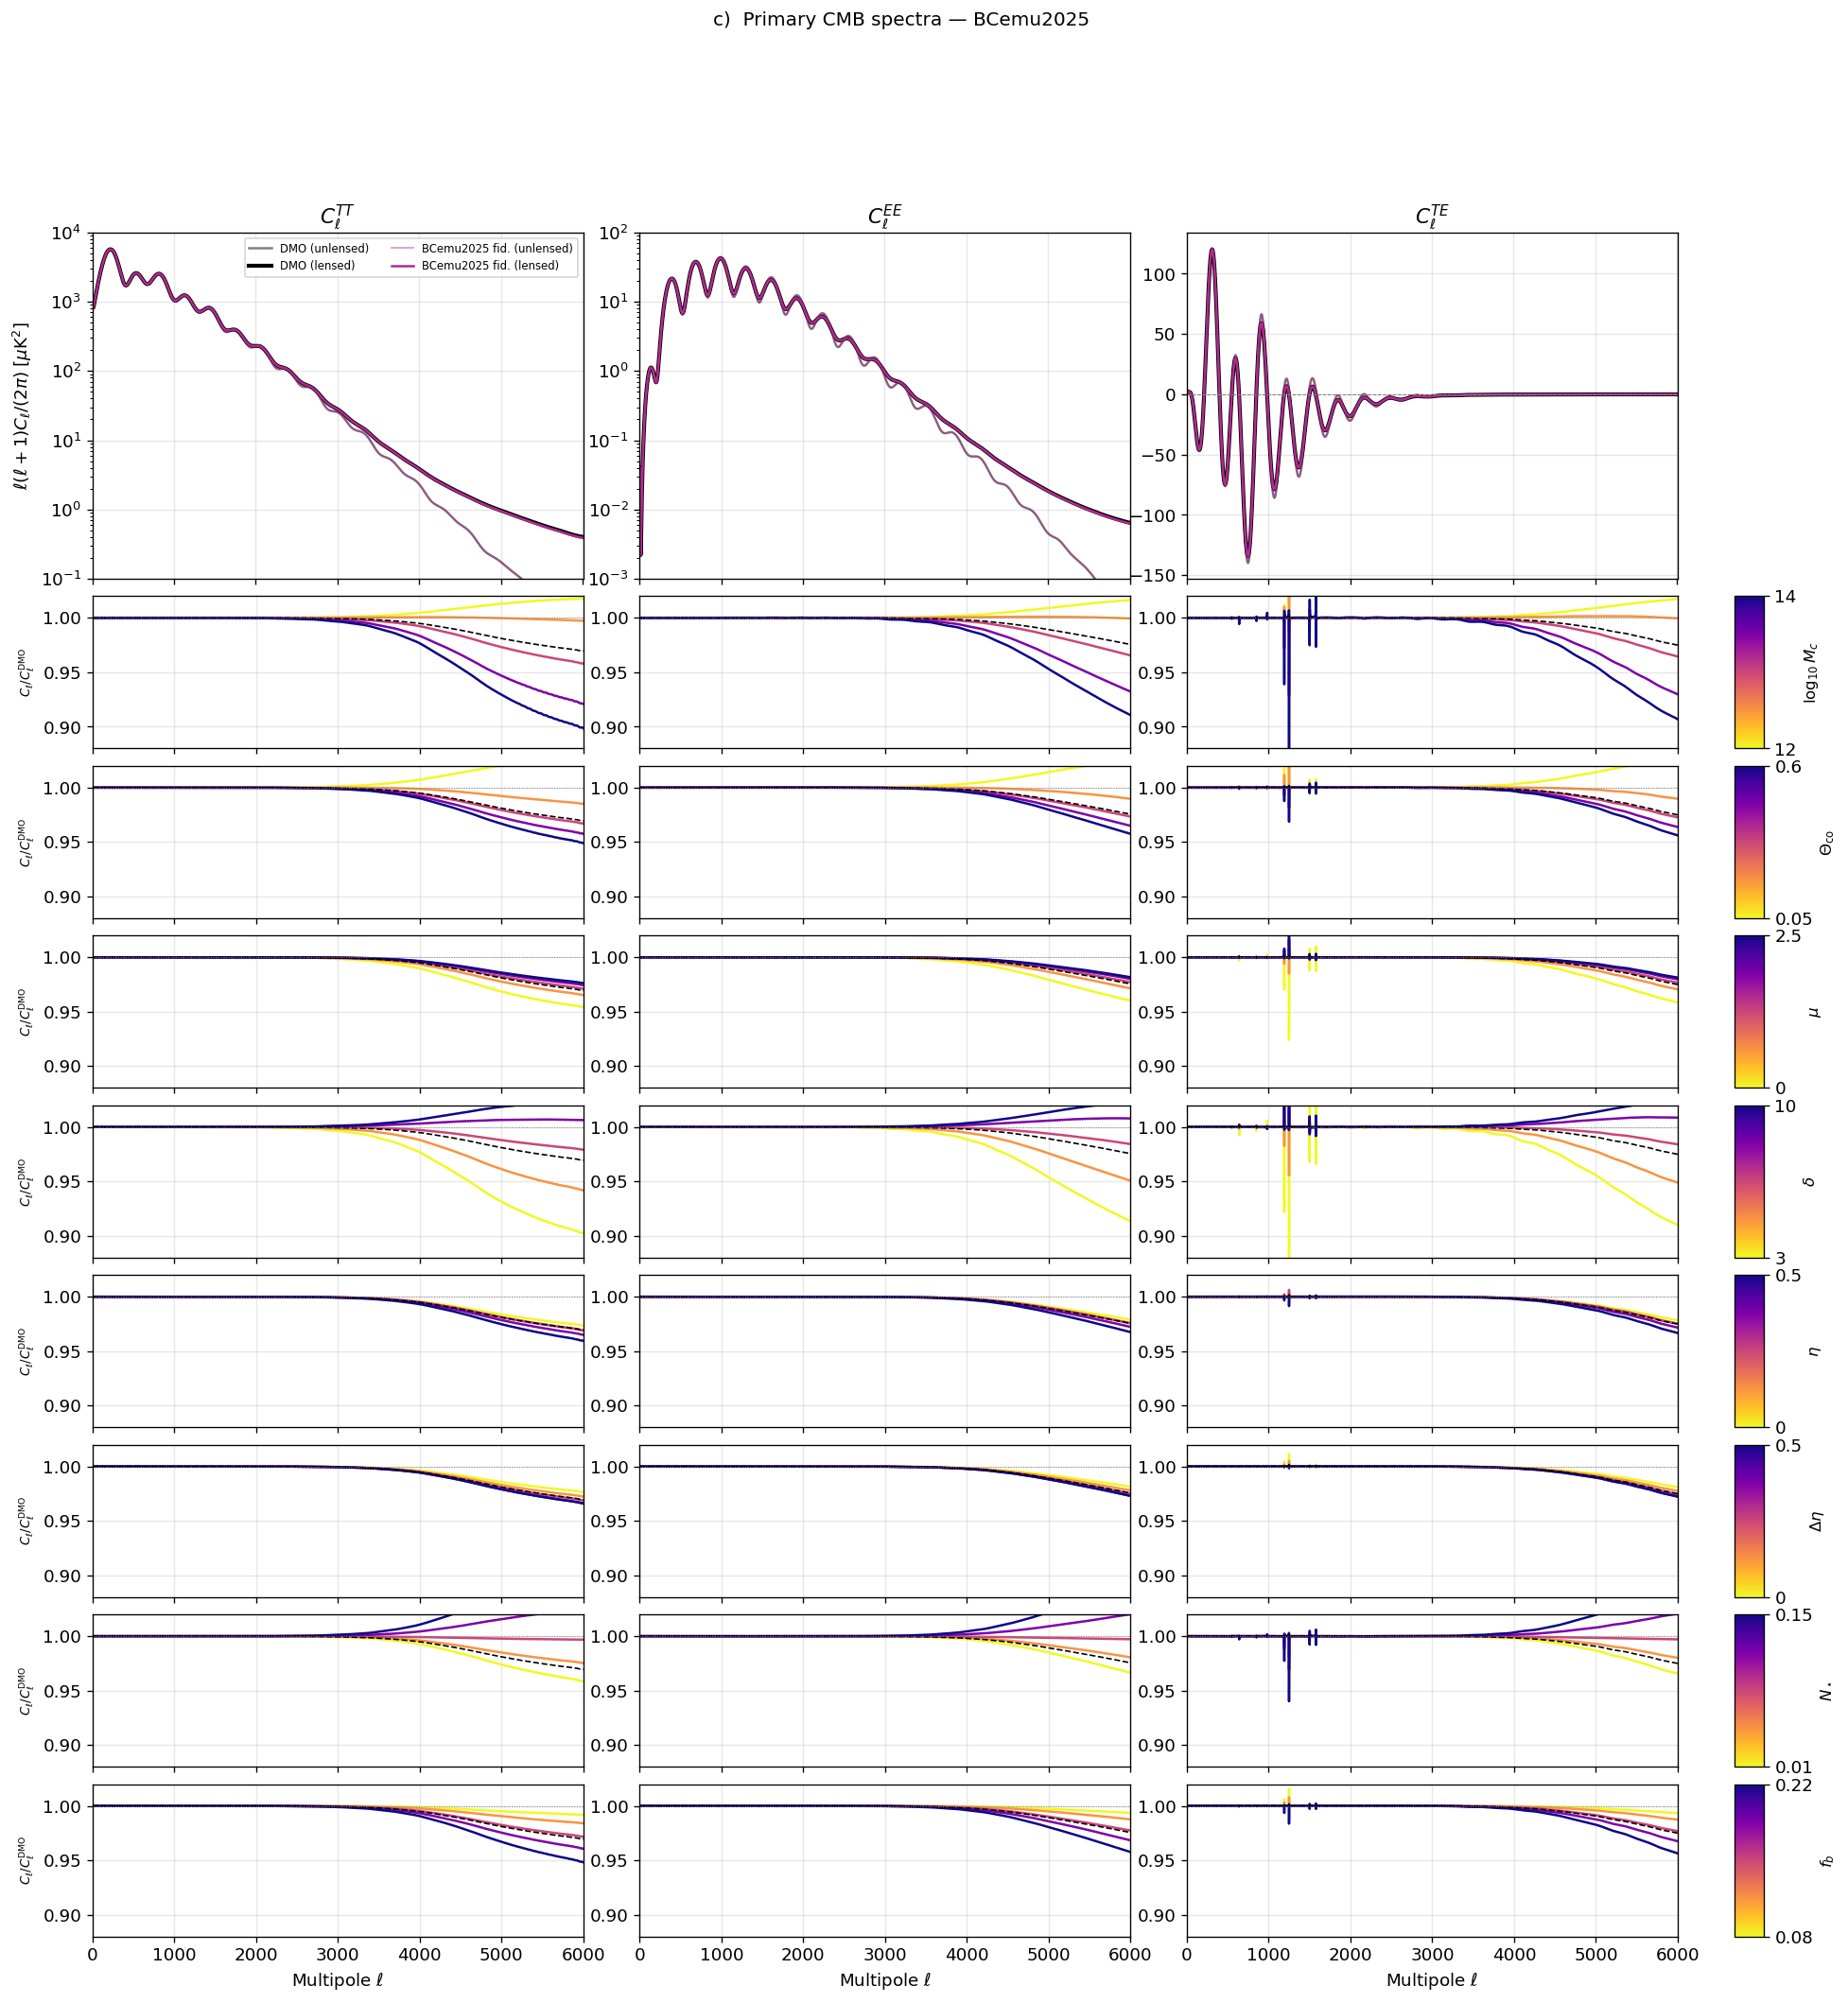

In [11]:
# ── c) Primary CMB spectra — fiducial (top) + per-parameter ratio rows ────────
import matplotlib.colors as mcolors

pnames   = list(PARAM_RANGES.keys())
n_params = len(pnames)
fid_c    = plt.get_cmap(CMAP_NAME)(0.6)

# 4-column gridspec: [TT | EE | TE | colorbar]
fig = plt.figure(figsize=(19, 3.5 + n_params * 2.0))
gs  = gridspec.GridSpec(
    n_params + 1, 4,
    height_ratios=[2.5] + [1.1] * n_params,
    width_ratios=[1.0, 1.0, 1.0, 0.06],
    hspace=0.10, wspace=0.15,
)

# ── top row: unlensed + lensed for DMO and fiducial BCemu2025 only ────────────
ax_tt = fig.add_subplot(gs[0, 0])
ax_ee = fig.add_subplot(gs[0, 1])
ax_te = fig.add_subplot(gs[0, 2])

for ax, ku, kl, ylim, title, ylabel in [
    (ax_tt, 'C_TT_unlensed', 'C_TT', (1e-1, 1e4),
     r'$C_\ell^{TT}$', r'$\ell(\ell+1)C_\ell/(2\pi)\;[\mu{\rm K}^2]$'),
    (ax_ee, 'C_EE_unlensed', 'C_EE', (1e-3, 1e2),
     r'$C_\ell^{EE}$', None),
    (ax_te, 'C_TE_unlensed', 'C_TE', None,
     r'$C_\ell^{TE}$',  None),
]:
    ax.plot(ell[mask], (prefactor * cmb_dmo[ku])[mask],
            'k-', lw=LW_DMO_UN, alpha=ALPHA_UN, label='DMO (unlensed)')
    ax.plot(ell[mask], (prefactor * cmb_dmo[kl])[mask],
            'k-', lw=LW_DMO, label='DMO (lensed)')
    ax.plot(ell[mask], (prefactor * cmb_fid[ku])[mask],
            '-', color=fid_c, lw=LW_MOD_UN, alpha=ALPHA_UN,
            label='BCemu2025 fid. (unlensed)')
    ax.plot(ell[mask], (prefactor * cmb_fid[kl])[mask],
            '-', color=fid_c, lw=LW_MOD, label='BCemu2025 fid. (lensed)')
    ax.set_xlim(0, 6010)
    ax.set_title(title, fontsize=13)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11)
    plt.setp(ax.get_xticklabels(), visible=False)

ax_tt.set_yscale('log'); ax_tt.set_ylim(1e-1, 1e4)
ax_ee.set_yscale('log'); ax_ee.set_ylim(1e-3, 1e2)
ax_te.axhline(0, color='gray', lw=0.6, ls='--')
ax_tt.legend(fontsize=7, ncol=2)

# ── ratio rows: one per BCemu2025 parameter ───────────────────────────────────
C_TT_dmo = cmb_dmo['C_TT'][mask]
C_EE_dmo = cmb_dmo['C_EE'][mask]
C_TE_dmo = cmb_dmo['C_TE'][mask]
C_TT_fid = cmb_fid['C_TT'][mask]
C_EE_fid = cmb_fid['C_EE'][mask]
C_TE_fid = cmb_fid['C_TE'][mask]

for irow, pname in enumerate(pnames):
    pmin, pmax = PARAM_RANGES[pname]
    cmap_p   = plt.get_cmap(CMAP_NAME)
    norm_p   = mcolors.Normalize(vmin=pmin, vmax=pmax)
    p_colors = [cmap_p(norm_p(v)) for v in sweep_vals[pname]]

    ax_rtt = fig.add_subplot(gs[irow + 1, 0])
    ax_ree = fig.add_subplot(gs[irow + 1, 1], sharex=ax_rtt)
    ax_rte = fig.add_subplot(gs[irow + 1, 2], sharex=ax_rtt)
    ax_cb  = fig.add_subplot(gs[irow + 1, 3])

    for ci, cmb_p in enumerate(sweep_cmb[pname]):
        ax_rtt.plot(ell[mask], cmb_p['C_TT'][mask] / C_TT_dmo,
                    color=p_colors[ci], lw=LW_MOD)
        ax_ree.plot(ell[mask], cmb_p['C_EE'][mask] / C_EE_dmo,
                    color=p_colors[ci], lw=LW_MOD)
        ax_rte.plot(ell[mask], cmb_p['C_TE'][mask] / C_TE_dmo,
                    color=p_colors[ci], lw=LW_MOD)

    # Fiducial as black dashed in every ratio panel
    ax_rtt.plot(ell[mask], C_TT_fid / C_TT_dmo, 'k--', lw=1.0)
    ax_ree.plot(ell[mask], C_EE_fid / C_EE_dmo, 'k--', lw=1.0)
    ax_rte.plot(ell[mask], C_TE_fid / C_TE_dmo, 'k--', lw=1.0)

    is_last = (irow == n_params - 1)
    for ax_r in (ax_rtt, ax_ree, ax_rte):
        ax_r.axhline(1.0, color='gray', lw=0.6, ls=':')
        ax_r.set_xlim(0, 6000)
        ax_r.set_ylim(0.88, 1.02)
        if is_last:
            ax_r.set_xlabel(r'Multipole $\ell$', fontsize=11)
        else:
            plt.setp(ax_r.get_xticklabels(), visible=False)

    ax_rtt.set_ylabel(r'$C_\ell/C_\ell^{\rm DMO}$', fontsize=8)

    # Per-row colorbar in the dedicated 4th column
    sm = plt.cm.ScalarMappable(cmap=cmap_p, norm=norm_p)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cb)
    cbar.set_label(PARAM_LATEX[pname], fontsize=10)
    cbar.set_ticks([pmin, pmax])
    cbar.set_ticklabels([f'{pmin:.2g}', f'{pmax:.2g}'])

fig.suptitle('c)  Primary CMB spectra — BCemu2025', fontsize=12)
plt.tight_layout()
plt.show()